In [1]:
%load_ext autoreload
%autoreload 2

import os
from torchvision import models
from torchvision import transforms
from PIL import Image
import torch
import pandas as  pd
import scipy.io as sio
import numpy as np
import glob
import natsort
from scipy.spatial.distance import cdist
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import helperFuns as helper
import cv2

# The module lives one level up from this notebook; add that parent explicitly
module_parent = str(Path.cwd().parent)
if module_parent not in sys.path:
    sys.path.insert(0, module_parent)
    print('Inserted', module_parent, 'into sys.path')
else:
    print('Parent already on sys.path:', module_parent)

# Add the helper functions directory to the path
helper_functions_path = Path(module_parent) / 'helperFunctions' / 'StimulusModeling'
if str(helper_functions_path) not in sys.path:
    sys.path.insert(0, str(helper_functions_path))

import stim_transformations as stf

Inserted /mnt/DataDrive3/emeyer/TreeShrewObjectRecognition into sys.path


In [2]:
img_size = 10
img_type = '.png'
img_set = 'isetbio'
taskName = 'Camel_v2_test_nn' #'Camel_v2_test_nn' 'Camel_Rhino_test_nn' , 'Camel_v2_test_nn', 'Camel_background_matrix'
projectpath = '/mnt/DataDrive3/emeyer/TreeShrewObjectRecognition/'
getDataPath = projectpath + '4_treeShrewBehavior/behaviorData/'
camel0 = 0

if taskName == 'Camel_Rhino_test_nn':
    distractor = 'rhino'
else:
    distractor = 'wrench'

img_folder = f'{projectpath}stimulusSets/isettreeshrew/treeshrew_{img_size}/{taskName}_quad/original/merged/'

In [3]:
train_targ_idx, train_dist_idx, avg_perf, targ_idx, dist_idx = helper.get_train_targdist_data(getDataPath,taskName)

# Load and sort images using natsort
img_files = natsort.natsorted(glob.glob(f'{img_folder}*{img_type}'))
all_names = [os.path.splitext(os.path.basename(img_file))[0].split('_') for img_file in img_files]

Y_labels = [name[0] for name in all_names]
unique_labels = np.unique(Y_labels)

# Format images into DNN input format split into target and distractor sets
DNN_input_targ, DNN_input_dist = helper.structure_isetbio_data(img_files, Y_labels, unique_labels, input_size = [227,227])

# RMS of the target images if needed
targ_std = DNN_input_targ.std(axis=(0, 1, 2))
dist_std = DNN_input_dist.std(axis=(0, 1, 2))

[ 0.  6.  9. 13. 17. 32. 38. 40. 44. 55. 60. 65.]
[ 0. 14. 26. 83. 87. 92. 93.]
402


In [4]:
# Restrict DNN inputs to indices from train_dist_idx and train_targ_idx
if taskName=='Camel_background_matrix':
    train_targ_idx = np.array(train_targ_idx).astype(int)-1
    train_dist_idx = np.array(train_dist_idx).astype(int)-1
else:
    train_targ_idx = np.array(train_targ_idx).astype(int)
    train_dist_idx = np.array(train_dist_idx).astype(int)

if img_set == 'salicon':
    restricted_DNN_input_targ = DNN_input_targ.copy()
    restricted_DNN_input_dist = DNN_input_dist.copy()
else:
    restricted_DNN_input_targ = DNN_input_targ[:, :, :, train_targ_idx]
    restricted_DNN_input_dist = DNN_input_dist[:, :, :, train_dist_idx]

restricted_DNN_input = np.concatenate((restricted_DNN_input_targ,restricted_DNN_input_dist),axis=3)

print("Restricted DNN input for targets shape:", restricted_DNN_input_targ.shape)
print("Restricted DNN input for distractors shape:", restricted_DNN_input_dist.shape)
print("Restricted DNN input= shape:", restricted_DNN_input.shape)

Restricted DNN input for targets shape: (227, 227, 3, 12)
Restricted DNN input for distractors shape: (227, 227, 3, 7)
Restricted DNN input= shape: (227, 227, 3, 19)


In [5]:
network = ['alexnet_mouse','alexnet','vgg16','resnet50']  # 'alexnet_mouse', 'alexnet', 'vgg16'
lay_types = ['ReLU','MaxPool2d','Linear']

# Initialize distances variable
# Initialize nested lists for activations
act_fc3_targ = [[] for _ in range(len(network))]
act_fc3_dist = [[] for _ in range(len(network))]
perfCorr = [[] for _ in range(len(network))]
distance = [dict() for _ in range(len(network))]
all_layers = []

for nn_idx, nn in enumerate(network):

    test_img = cv2.imread(f'{img_folder}camel_{0}.png', cv2.IMREAD_GRAYSCALE)
    _, model_layers = stf.transform_image(test_img, operation='NN', layer_types = lay_types, network=nn)
    # print(model_layers)
    act_fc3_targ[nn_idx] = [[] for _ in range(len(model_layers))]
    act_fc3_dist[nn_idx] = [[] for _ in range(len(model_layers))]
    all_layers.append(model_layers)

    for lay_idx, layers in enumerate(model_layers):
        print(layers)
        for tt_idx, tt in enumerate(train_targ_idx):
            # Load the original image and convert to grayscale
            img = Image.open(f'{img_folder}camel_{tt}.png')
            img = np.array(img)

            act, _ = stf.transform_image(img, operation='NN', layer_types = lay_types , network=nn)
            act_fc3_targ[nn_idx][lay_idx].append(act[lay_idx].flatten())
        
        for dd_idx, dd in enumerate(train_dist_idx):
            # Load the original image and convert to grayscale
            img = Image.open(f'{img_folder}{distractor}_{dd}.png')
            img = np.array(img)

            act, _ = stf.transform_image(img, operation='NN', layer_types = lay_types, network=nn)
            act_fc3_dist[nn_idx][lay_idx].append(act[lay_idx].flatten())

        # Compute target-distractor distance matrix for each model and layer
        distance[nn_idx][layers] = cdist(np.array(act_fc3_targ[nn_idx][lay_idx]), np.array(act_fc3_dist[nn_idx][lay_idx]), metric='euclidean')

        perfCorr[nn_idx].append(np.corrcoef(avg_perf.flatten(),distance[nn_idx][layers].flatten())[0,1])

Loading alexnet_bn_ir_64x64_input_pool_6. Pretrained: True. Model Family: imagenet.
Loaded parameters from ../mouse_vision/model_ckpts/alexnet_bn_ir.pt
ReLU: features.2
Loading alexnet_bn_ir_64x64_input_pool_6. Pretrained: True. Model Family: imagenet.
Loaded parameters from ../mouse_vision/model_ckpts/alexnet_bn_ir.pt
Loading alexnet_bn_ir_64x64_input_pool_6. Pretrained: True. Model Family: imagenet.
Loaded parameters from ../mouse_vision/model_ckpts/alexnet_bn_ir.pt
Loading alexnet_bn_ir_64x64_input_pool_6. Pretrained: True. Model Family: imagenet.
Loaded parameters from ../mouse_vision/model_ckpts/alexnet_bn_ir.pt
Loading alexnet_bn_ir_64x64_input_pool_6. Pretrained: True. Model Family: imagenet.
Loaded parameters from ../mouse_vision/model_ckpts/alexnet_bn_ir.pt
Loading alexnet_bn_ir_64x64_input_pool_6. Pretrained: True. Model Family: imagenet.
Loaded parameters from ../mouse_vision/model_ckpts/alexnet_bn_ir.pt
Loading alexnet_bn_ir_64x64_input_pool_6. Pretrained: True. Model Famil

/home/arcarolab_adm/anaconda3/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/arcarolab_adm/anaconda3/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ReLU: features.1
MaxPool2d: features.2
ReLU: features.4
MaxPool2d: features.5
ReLU: features.7
ReLU: features.9
ReLU: features.11
MaxPool2d: features.12
Linear: classifier.1
ReLU: classifier.2
Linear: classifier.4
ReLU: classifier.5
Linear: classifier.6


/home/arcarolab_adm/anaconda3/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ReLU: features.1
ReLU: features.3
MaxPool2d: features.4
ReLU: features.6
ReLU: features.8
MaxPool2d: features.9
ReLU: features.11
ReLU: features.13
ReLU: features.15
MaxPool2d: features.16
ReLU: features.18
ReLU: features.20
ReLU: features.22
MaxPool2d: features.23
ReLU: features.25
ReLU: features.27
ReLU: features.29
MaxPool2d: features.30
Linear: classifier.0
ReLU: classifier.1
Linear: classifier.3
ReLU: classifier.4
Linear: classifier.6


/home/arcarolab_adm/anaconda3/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to ../mouse_vision/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 110MB/s] 


ReLU: relu
MaxPool2d: maxpool
ReLU: layer1.0.relu
ReLU: layer1.1.relu
ReLU: layer1.2.relu
ReLU: layer2.0.relu
ReLU: layer2.1.relu
ReLU: layer2.2.relu
ReLU: layer2.3.relu
ReLU: layer3.0.relu
ReLU: layer3.1.relu
ReLU: layer3.2.relu
ReLU: layer3.3.relu
ReLU: layer3.4.relu
ReLU: layer3.5.relu
ReLU: layer4.0.relu
ReLU: layer4.1.relu
ReLU: layer4.2.relu
Linear: fc


[-0.13144727876031242, -0.17205991876503923, -0.1820147111306371, -0.1925298044681461, -0.19350579782813557, 0.15945097294665564, 0.08012160619231795]
[-0.14646365303367534, -0.05658483837250597, -0.12364043808218454, -0.10413915593461648, -0.16310407767932805, -0.0021646379690313106, -0.047609113481289184, 0.03392036804798011]
[0.013204146966210981, 0.08137166870114608, -0.02135174058294196, -0.1569274371350958, -0.20029533238764835, 0.04850743926937974, 0.15986048368435837, 0.14640968231907225]
[-0.04337553959303, -0.005789829887466858, -0.01567566806590361, 0.00529195863406071, -0.06406682860915297, -0.052814376931735206]


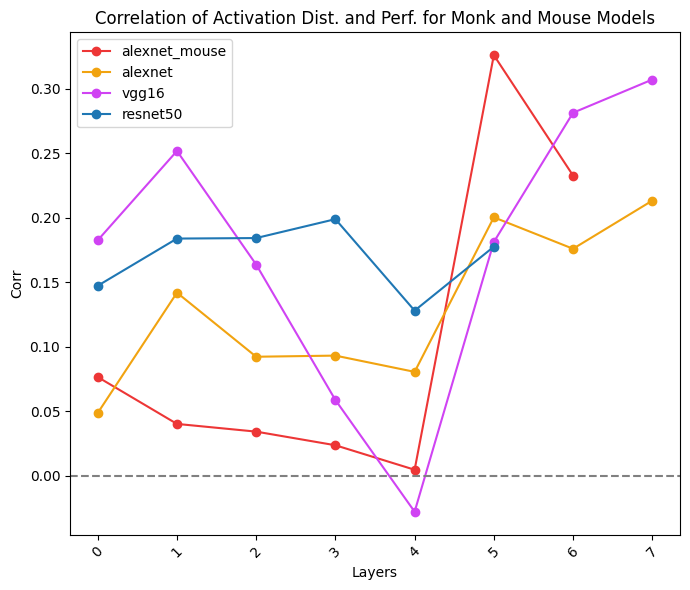

In [ ]:
# network = ['alexnet_mouse','alexnet','vgg16']  # 'alexnet_mouse', 'alexnet', 'vgg16'
colors = ["#ed3636","#f1a310","#d043f3","#1f77b4"]  # Red, Orange, Purple, Blue

plt.figure(figsize=(7, 6))
for nn_idx, nn in enumerate(network):

    correlation, ci_upper, ci_lower, shuff_upper, shuff_lower = helper.compute_correlation(avg_perf, distance[nn_idx])
    if nn == 'alexnet_mouse':
        model_layers = ['MaxPool2d: features.3', 'MaxPool2d: features.7', 'ReLU: features.10', 'ReLU: features.13', 'MaxPool2d: features.17', 'Linear: classifier.1', 'Linear: classifier.5']
    elif nn == 'alexnet':
        model_layers = ['MaxPool2d: features.2','MaxPool2d: features.5','ReLU: features.7','ReLU: features.9','MaxPool2d: features.12','Linear: classifier.1','Linear: classifier.4','Linear: classifier.6']
    elif nn == 'vgg16':
        model_layers = ['MaxPool2d: features.4','MaxPool2d: features.9','MaxPool2d: features.16','MaxPool2d: features.23','MaxPool2d: features.30','Linear: classifier.0','Linear: classifier.3','Linear: classifier.6']
    elif nn == 'resnet50':
        model_layers = ['MaxPool2d: maxpool','ReLU: layer1.2.relu', 'ReLU: layer2.3.relu','ReLU: layer3.5.relu', 'ReLU: layer4.2.relu','Linear: fc']

    corrData = []
    ciData_lower = []
    ciData_upper = []
    shuffData_lower = []
    shuffData_upper = []
    for lay_idx, layer in enumerate(correlation.keys()):
        if layer in model_layers:
            corrData.append(correlation[layer])
            ciData_lower.append(ci_lower[layer])
            ciData_upper.append(ci_upper[layer])
            shuffData_lower.append(shuff_lower[layer])
            shuffData_upper.append(shuff_upper[layer])

    plt.plot(range(len(model_layers)), corrData, label=network[nn_idx], marker='o', color=colors[nn_idx])
    # plt.fill_between(range(len(model_layers)), ciData_lower, ciData_upper, color=colors[nn_idx], alpha=0.2)
    print(ciData_upper)

plt.axhline(0, color='gray', linestyle='--')

# Adding labels and title
plt.xlabel('Layers')
plt.ylabel('Corr')
plt.title('Correlation of Activation Dist. and Perf. for Monk and Mouse Models')
plt.xticks(rotation=45)
plt.legend()
plt.grid(False)
plt.tight_layout()

plt.savefig('./figures/perf_act_correlation_'+ taskName+'.svg', format='svg')
plt.savefig('./figures/perf_act_correlation_'+ taskName+'.png', format='png')
plt.show()
